# CS3807 – Deep Learning Laboratory
## Experiment 6: End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

**Shiv Nadar University Chennai | B.Tech AI & Data Science | AY 2026–27**

This notebook covers:
1. HAR sensor-sequence classification with SimpleRNN, LSTM, GRU
2. BPTT numerical exercise
3. Effect of sequence length (T = 32, 64, 128)
4. Video understanding with CNN (MobileNetV2) + LSTM/GRU on a UCF101 subset
5. Sequence-to-sequence learning (encoder–decoder LSTM) on a synthetic reversal task

Run top to bottom on a **Colab GPU runtime** (Runtime → Change runtime type → GPU).


## 1. Setup

In [ ]:
!pip -q install pydot >/dev/null 2>&1
import os, time, random, math, zipfile, io, glob, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(gpus), gpus)


TensorFlow: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset — UCI HAR (raw inertial signals)

We use the classic **UCI HAR Dataset** zip, which already ships the raw inertial signals
pre-windowed as `128 x 9` (9 = 3-axis body acc + 3-axis body gyro + 3-axis total acc),
exactly matching the `X ∈ R^{N×128×9}` format the manual asks for — so no manual windowing
is needed, only loading + relabeling + our own 70/15/15 split.


In [ ]:
DATA_DIR = "/content/UCI_HAR"
ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "/content/uci_har.zip"

if not os.path.exists(DATA_DIR):
    print("Downloading UCI HAR Dataset ...")
    import urllib.request
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    shutil.move("/content/UCI HAR Dataset", DATA_DIR)
    print("Done.")
else:
    print("Already downloaded.")

SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z",
           "body_gyro_x", "body_gyro_y", "body_gyro_z",
           "total_acc_x", "total_acc_y", "total_acc_z"]

def load_signals(split):
    base = os.path.join(DATA_DIR, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        path = os.path.join(base, f"{sig}_{split}.txt")
        channels.append(np.loadtxt(path))          # (N, 128)
    X = np.stack(channels, axis=-1)                 # (N, 128, 9)
    return X

def load_labels(split):
    path = os.path.join(DATA_DIR, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int) - 1         # 0-indexed, 6 classes

X_train_raw = load_signals("train")
X_test_raw  = load_signals("test")
y_train_raw = load_labels("train")
y_test_raw  = load_labels("test")

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
              "SITTING", "STANDING", "LAYING"]

X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)
print("Combined:", X_all.shape, y_all.shape)


Done.
Combined: (10299, 128, 9) (10299,)


### 2.1 Train / Validation / Test split (70 / 15 / 15, stratified)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print("Input tensor shape:")
print("  Training  :", X_train.shape)
print("  Validation:", X_val.shape)
print("  Testing   :", X_test.shape)
print("Number of classes:", len(ACTIVITIES))
print("Number of features per time step:", X_train.shape[-1])
print("Sequence length:", X_train.shape[1])

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = np.bincount(y, minlength=6)
    print(name, dict(zip(ACTIVITIES, counts)))


Input tensor shape:
  Training  : (7209, 128, 9)
  Validation: (1545, 128, 9)
  Testing   : (1545, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128
train {'WALKING': np.int64(1205), 'WALKING_UPSTAIRS': np.int64(1081), 'WALKING_DOWNSTAIRS': np.int64(984), 'SITTING': np.int64(1244), 'STANDING': np.int64(1334), 'LAYING': np.int64(1361)}
val {'WALKING': np.int64(258), 'WALKING_UPSTAIRS': np.int64(232), 'WALKING_DOWNSTAIRS': np.int64(211), 'SITTING': np.int64(266), 'STANDING': np.int64(286), 'LAYING': np.int64(292)}
test {'WALKING': np.int64(259), 'WALKING_UPSTAIRS': np.int64(231), 'WALKING_DOWNSTAIRS': np.int64(211), 'SITTING': np.int64(267), 'STANDING': np.int64(286), 'LAYING': np.int64(291)}


### 2.2 Normalization (statistics from training data only)

In [ ]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_val_n   = (X_val   - mean) / std
X_test_n  = (X_test  - mean) / std

print("Post-normalization train mean/std (should be ~0/~1):",
      X_train_n.mean().round(3), X_train_n.std().round(3))


Post-normalization train mean/std (should be ~0/~1): -0.0 1.0


## 3. Temporal Data Visualization (Plot 1)

Sensor signal vs time for at least 3 channels, across at least 3 activity classes.


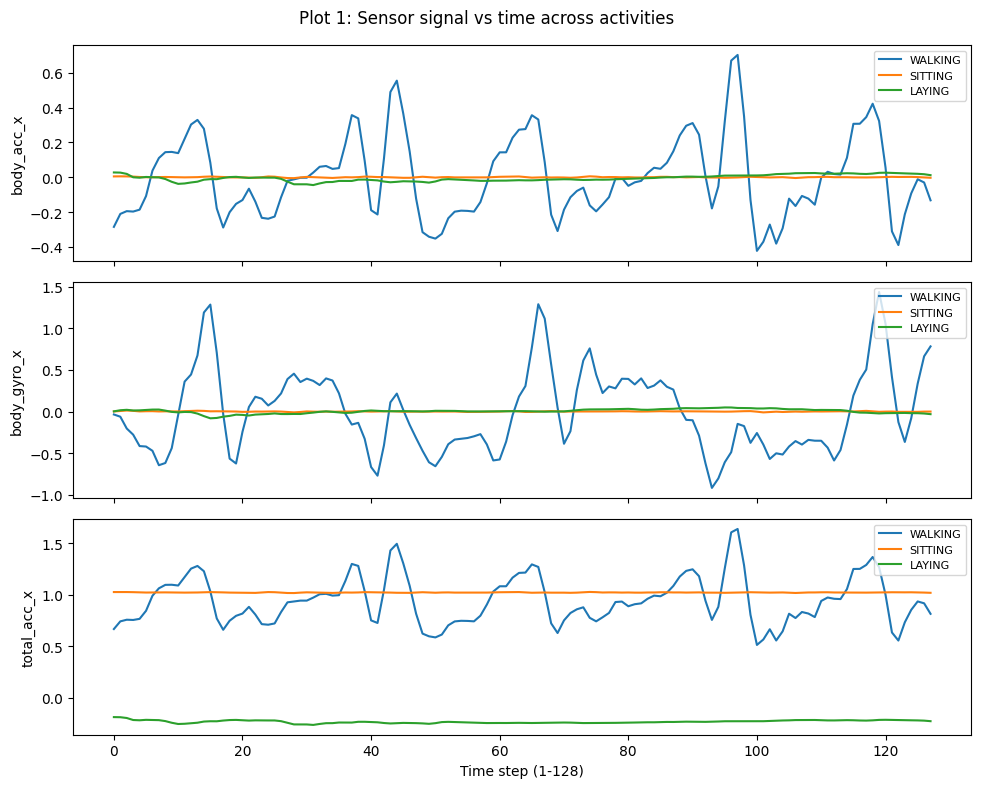

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
channels_to_plot = [0, 3, 6]   # body_acc_x, body_gyro_x, total_acc_x
channel_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
classes_to_plot = [0, 3, 5]    # WALKING, SITTING, LAYING

for ax, ch, cname in zip(axes, channels_to_plot, channel_names):
    for cls in classes_to_plot:
        idx = np.where(y_train == cls)[0][0]
        ax.plot(X_train[idx, :, ch], label=ACTIVITIES[cls])
    ax.set_ylabel(cname)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
fig.suptitle("Plot 1: Sensor signal vs time across activities")
plt.tight_layout()
plt.show()

# Required inference:
# 1. Temporal pattern: WALKING shows strong periodic oscillation (footstep cycles);
#    SITTING/LAYING are near-flat/low-variance since the body is static.
# 2. Similar patterns: SITTING and STANDING look most alike (both static, low-motion) —
#    they're the pair most likely to be confused later in the confusion matrix.
# 3. Order matters because activity is defined by the *shape* of motion over time, not by
#    isolated readings; shuffling time steps would destroy the periodicity that separates
#    WALKING-type activities from static ones.


## 4. BPTT Numerical Exercise (Section 8)

Manual computation vs program, using $h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$.


In [ ]:
def rnn_step(x, h_prev, Wx=0.5, Wh=0.8, b=0.1):
    return math.tanh(Wx * x + Wh * h_prev + b)

x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0.0

h1 = rnn_step(x1, h0)
h2 = rnn_step(x2, h1)
h3 = rnn_step(x3, h2)

print(f"h1 = {h1:.6f}")
print(f"h2 = {h2:.6f}")
print(f"h3 = {h3:.6f}")
# Compare these three values against your by-hand calculation in the report.


h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


## 5. RNN / LSTM / GRU — Model Builder

Same architecture template for all three, only the recurrent layer changes, so the
comparison is controlled as the manual requires.


In [ ]:
def build_model(cell_type, units=32, T=128, F=9, n_classes=6):
    inp = Input(shape=(T, F))
    if cell_type == "RNN":
        x = layers.SimpleRNN(units)(inp)
    elif cell_type == "LSTM":
        x = layers.LSTM(units)(inp)
    elif cell_type == "GRU":
        x = layers.GRU(units)(inp)
    else:
        raise ValueError(cell_type)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def train_model(cell_type, Xtr, ytr, Xval, yval, epochs=30, batch_size=32, verbose=0):
    tf.random.set_seed(SEED)
    model = build_model(cell_type, T=Xtr.shape[1], F=Xtr.shape[2])
    t0 = time.time()
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval),
                      epochs=epochs, batch_size=batch_size, verbose=verbose)
    train_time = time.time() - t0
    n_params = model.count_params()
    return model, hist, train_time, n_params


## 6. Train RNN, LSTM, GRU (full sequence, T = 128)

In [ ]:
results = {}
histories = {}

for cell in ["RNN", "LSTM", "GRU"]:
    print(f"Training {cell} ...")
    model, hist, t_time, n_params = train_model(cell, X_train_n, y_train, X_val_n, y_val, verbose=1)
    results[cell] = {"model": model, "train_time": t_time, "n_params": n_params}
    histories[cell] = hist.history
    print(f"{cell}: {n_params} params, {t_time:.1f}s\n")


Training RNN ...
Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.4751 - loss: 1.3286 - val_accuracy: 0.5385 - val_loss: 1.0388
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6084 - loss: 0.9118 - val_accuracy: 0.6764 - val_loss: 0.7499
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6646 - loss: 0.7250 - val_accuracy: 0.6906 - val_loss: 0.6475
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6878 - loss: 0.6586 - val_accuracy: 0.7165 - val_loss: 0.6385
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7102 - loss: 0.6274 - val_accuracy: 0.7605 - val_loss: 0.5749
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7202 - loss: 0.7056 - val_accuracy: 0.7398 - val_loss: 0.6243
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7227 - loss: 0.6206 - val_accuracy: 0.7767 - val_loss: 0.5468
Epoch 8/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7413 - loss:

### 6.1 Training/Validation curves (Plot 2 — Loss, Plot 3 — Accuracy)

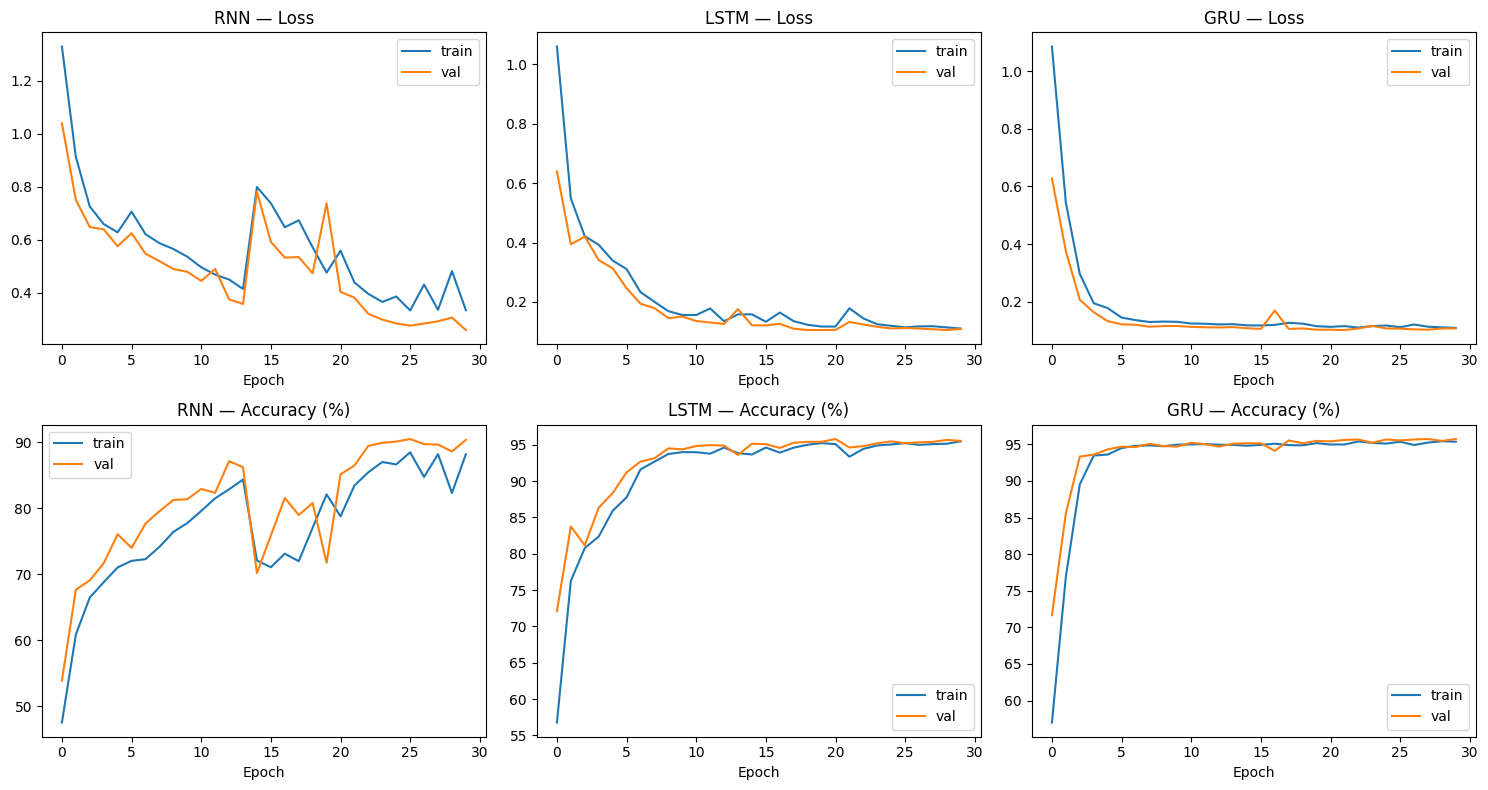

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, cell in enumerate(["RNN", "LSTM", "GRU"]):
    h = histories[cell]
    axes[0, i].plot(h["loss"], label="train")
    axes[0, i].plot(h["val_loss"], label="val")
    axes[0, i].set_title(f"{cell} — Loss")
    axes[0, i].set_xlabel("Epoch"); axes[0, i].legend()

    axes[1, i].plot([a*100 for a in h["accuracy"]], label="train")
    axes[1, i].plot([a*100 for a in h["val_accuracy"]], label="val")
    axes[1, i].set_title(f"{cell} — Accuracy (%)")
    axes[1, i].set_xlabel("Epoch"); axes[1, i].legend()
plt.tight_layout()
plt.show()

# Required inference (fill in after observing your own curves):
# - Convergence: does val_loss flatten/rise while train_loss keeps falling (overfitting)?
# - Which model converges fastest / most smoothly, and why (gating vs plain RNN)?


## 7. Test-set Evaluation (Plot 4 — Confusion Matrices)

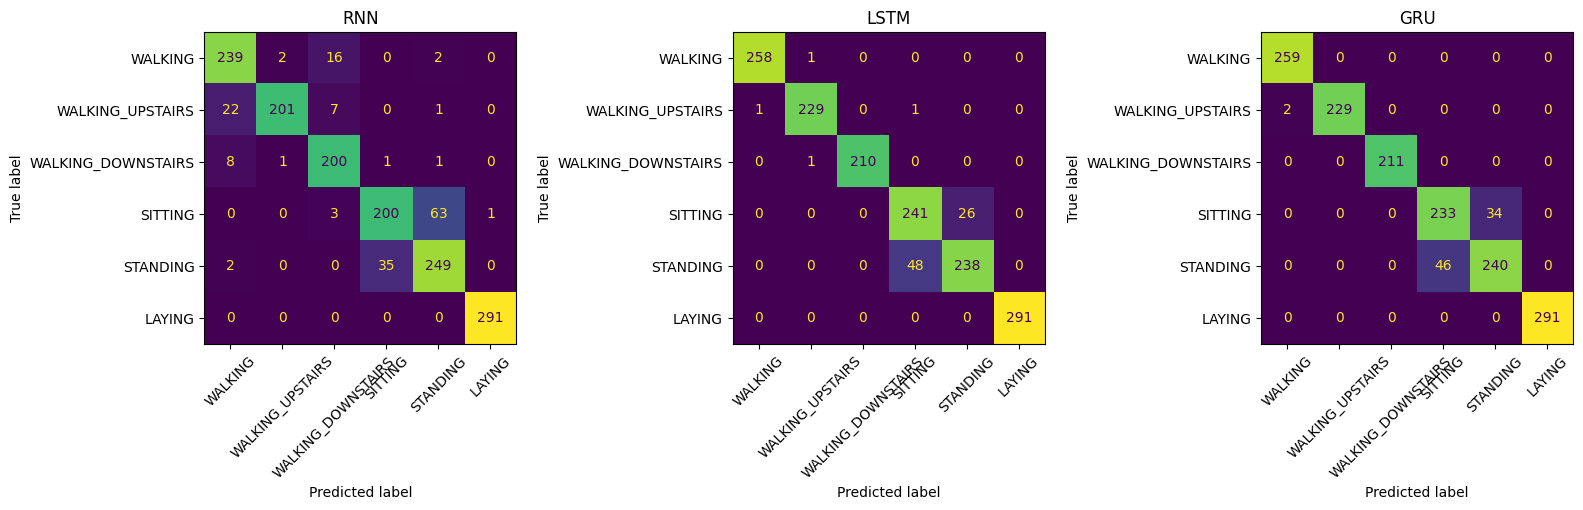

RNN: acc=89.32%  P=89.74%  R=89.34%  F1=89.37%  params=1974  time=94.5s
LSTM: acc=94.95%  P=95.33%  R=95.29%  F1=95.27%  params=6006  time=74.7s
GRU: acc=94.69%  P=95.06%  R=95.05%  F1=95.04%  params=4758  time=75.6s


In [ ]:
def evaluate_model(model, Xte, yte):
    y_prob = model.predict(Xte, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    return {
        "accuracy": accuracy_score(yte, y_pred) * 100,
        "precision": precision_score(yte, y_pred, average="macro", zero_division=0) * 100,
        "recall": recall_score(yte, y_pred, average="macro", zero_division=0) * 100,
        "f1": f1_score(yte, y_pred, average="macro", zero_division=0) * 100,
        "y_pred": y_pred,
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cell in zip(axes, ["RNN", "LSTM", "GRU"]):
    metrics = evaluate_model(results[cell]["model"], X_test_n, y_test)
    results[cell].update(metrics)
    cm = confusion_matrix(y_test, metrics["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=ACTIVITIES).plot(
        ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(cell)
plt.tight_layout()
plt.show()

for cell in ["RNN", "LSTM", "GRU"]:
    r = results[cell]
    print(f"{cell}: acc={r['accuracy']:.2f}%  P={r['precision']:.2f}%  "
          f"R={r['recall']:.2f}%  F1={r['f1']:.2f}%  "
          f"params={r['n_params']}  time={r['train_time']:.1f}s")

# Required inference: identify (from YOUR matrices) the best-recognized activity, the
# most-confused pair (commonly SITTING <-> STANDING for this dataset), and whether the
# confusion pattern is consistent across all three models.


## 8. Comparison Table + Bar Plot (Plot 5)

,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
RNN,89.320388,89.736272,89.341169,89.368540,1974.0,94.544603
LSTM,94.951456,95.333844,95.292187,95.265172,6006.0,74.706596
GRU,94.692557,95.056250,95.052700,95.040479,4758.0,75.632475


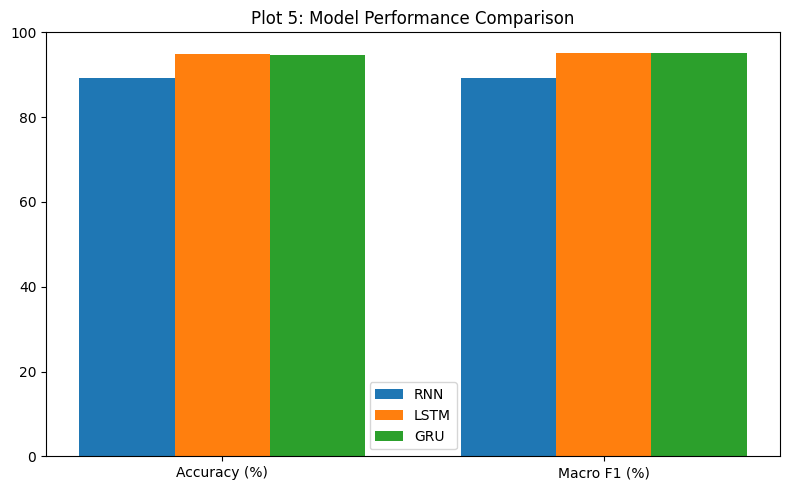

In [ ]:
comparison_df = pd.DataFrame({
    cell: {
        "Accuracy (%)": results[cell]["accuracy"],
        "Macro Precision (%)": results[cell]["precision"],
        "Macro Recall (%)": results[cell]["recall"],
        "Macro F1 (%)": results[cell]["f1"],
        "Parameters": results[cell]["n_params"],
        "Training Time (s)": results[cell]["train_time"],
    } for cell in ["RNN", "LSTM", "GRU"]
}).T
display(comparison_df)

fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ["Accuracy (%)", "Macro F1 (%)"]
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, cell in enumerate(["RNN", "LSTM", "GRU"]):
    vals = [comparison_df.loc[cell, m] for m in metrics_to_plot]
    ax.bar(x + i*width, vals, width, label=cell)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_title("Plot 5: Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

# Required inference: discuss the Predictive Performance <-> Model Complexity <-> Training
# Cost trade-off using the numbers in comparison_df.


## 9. Effect of Sequence Length — T ∈ {32, 64, 128} (Plot 6)

T=32, RNN ...
  F1=90.30%
T=32, LSTM ...
  F1=94.35%
T=32, GRU ...
  F1=94.49%
T=64, RNN ...
  F1=86.55%
T=64, LSTM ...
  F1=95.01%
T=64, GRU ...
  F1=94.82%
T=128, RNN ...
  F1=82.48%
T=128, LSTM ...
  F1=94.82%
T=128, GRU ...
  F1=95.36%


,RNN,LSTM,GRU
Sequence Length,,,
32,90.296374,94.350608,94.490973
64,86.547712,95.012454,94.820352
128,82.482537,94.821313,95.358407


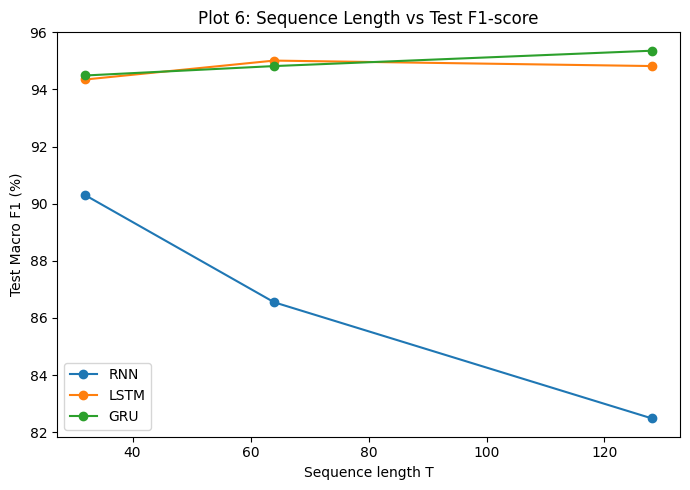

In [ ]:
def truncate(X, T):
    # keep the LAST T time steps (closest to the end of the window)
    return X[:, -T:, :]

seqlen_results = {cell: {} for cell in ["RNN", "LSTM", "GRU"]}

for T in [32, 64, 128]:
    Xtr_T = truncate(X_train_n, T)
    Xval_T = truncate(X_val_n, T)
    Xte_T = truncate(X_test_n, T)
    for cell in ["RNN", "LSTM", "GRU"]:
        print(f"T={T}, {cell} ...")
        model, hist, t_time, n_params = train_model(cell, Xtr_T, y_train, Xval_T, y_val,
                                                      epochs=20, verbose=0)
        m = evaluate_model(model, Xte_T, y_test)
        seqlen_results[cell][T] = m["f1"]
        print(f"  F1={m['f1']:.2f}%")

seqlen_df = pd.DataFrame(seqlen_results)
seqlen_df.index.name = "Sequence Length"
display(seqlen_df)

fig, ax = plt.subplots(figsize=(7, 5))
for cell in ["RNN", "LSTM", "GRU"]:
    ax.plot([32, 64, 128], [seqlen_results[cell][T] for T in [32, 64, 128]],
            marker="o", label=cell)
ax.set_xlabel("Sequence length T")
ax.set_ylabel("Test Macro F1 (%)")
ax.set_title("Plot 6: Sequence Length vs Test F1-score")
ax.legend()
plt.tight_layout()
plt.show()

# Required inference: shorter T means less temporal context per sample — expect RNN to
# degrade fastest (weak long-range memory even at T=128), LSTM/GRU to be more robust.


## 10. Video Understanding: CNN + LSTM/GRU

We use the small **UCF101 subset** published by the official TensorFlow "Load video data"
tutorial (5 action classes, a handful of clips each) instead of the full multi-GB UCF101,
per the manual's "select 3–5 classes, small number of videos" instruction.


In [ ]:
# The original download.tensorflow.org tar link now 403s for some accounts/regions,
# so we fall back to a Hugging Face mirror of the exact same TF-tutorial-generated subset.
VIDEO_URLS = [
    "https://storage.googleapis.com/download.tensorflow.org/data/UCF101_subset.tar",
    "https://huggingface.co/datasets/aisuko/ucf101-subset/resolve/main/UCF101_subset.tar.gz",
]
VIDEO_DIR = "/content/UCF101_subset"

if not os.path.exists(VIDEO_DIR):
    import urllib.request, tarfile
    tar_path = "/content/ucf101_subset.tar"
    for url in VIDEO_URLS:
        try:
            print(f"Trying {url} ...")
            urllib.request.urlretrieve(url, tar_path)
            print("Downloaded from", url)
            break
        except Exception as e:
            print(f"  failed ({e}), trying next mirror ...")
    else:
        raise RuntimeError("All UCF101 subset mirrors failed to download.")
    with tarfile.open(tar_path) as t:   # auto-detects .tar vs .tar.gz
        t.extractall("/content/")
    print("Extracted.")

# Dataset ships as UCF101_subset/{train,val,test}/{class_name}/*.avi
video_classes = sorted(os.listdir(os.path.join(VIDEO_DIR, "train")))
print("Classes:", video_classes)

def gather_videos(split):
    rows = []
    for cls in video_classes:
        folder = os.path.join(VIDEO_DIR, split, cls)
        for f in glob.glob(os.path.join(folder, "*.avi")):
            rows.append((f, cls))
    return rows

train_videos = gather_videos("train")
val_videos = gather_videos("val")
test_videos = gather_videos("test")
print(len(train_videos), len(val_videos), len(test_videos), "videos (train/val/test)")


Classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']
300 30 75 videos (train/val/test)


### 10.1 Frame extraction + MobileNetV2 feature extraction

In [ ]:
import cv2

N_FRAMES = 10
IMG_SIZE = 224

def sample_frames(video_path, n_frames=N_FRAMES, size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.resize(frame, (size, size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    while len(frames) < n_frames and frames:
        frames.append(frames[-1])            # pad short videos by repeating last frame
    return np.array(frames[:n_frames])

feature_extractor = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False,
    weights="imagenet", pooling="avg")
feature_extractor.trainable = False           # freeze — CNN is NOT trained

FEATURE_DIM = feature_extractor.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def video_to_features(video_path):
    frames = sample_frames(video_path)
    frames_pre = tf.keras.applications.mobilenet_v2.preprocess_input(frames.astype("float32"))
    feats = feature_extractor.predict(frames_pre, verbose=0)   # (10, D)
    return feats

class_to_idx = {c: i for i, c in enumerate(video_classes)}

def build_feature_dataset(video_list):
    X, y = [], []
    for path, cls in video_list:
        X.append(video_to_features(path))
        y.append(class_to_idx[cls])
    return np.array(X), np.array(y)

print("Extracting features (this can take a few minutes) ...")
Xv_train, yv_train = build_feature_dataset(train_videos)
Xv_val, yv_val = build_feature_dataset(val_videos)
Xv_test, yv_test = build_feature_dataset(test_videos)
print("Feature tensor shapes:", Xv_train.shape, Xv_val.shape, Xv_test.shape)
# Expected: (B, 10, D) supplied to the recurrent network, as required by the manual.


CNN feature dimension D = 1280
Extracting features (this can take a few minutes) ...
Feature tensor shapes: (300, 10, 1280) (30, 10, 1280) (75, 10, 1280)


### 10.2 Sample frames (Plot 7)

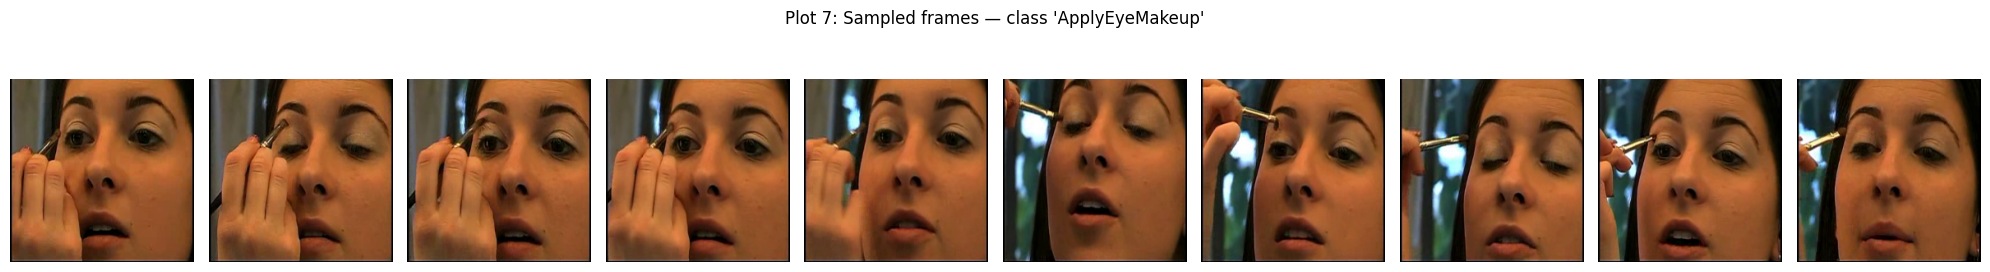

In [ ]:
sample_path, sample_cls = train_videos[0]
frames = sample_frames(sample_path)
fig, axes = plt.subplots(1, N_FRAMES, figsize=(20, 3))
for ax, f in zip(axes, frames):
    ax.imshow(f); ax.axis("off")
fig.suptitle(f"Plot 7: Sampled frames — class '{sample_cls}'")
plt.tight_layout()
plt.show()


### 10.3 CNN–LSTM / CNN–GRU classifier, training curves (Plot 8), confusion matrix (Plot 9)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4533 - loss: 1.7512 - val_accuracy: 0.7333 - val_loss: 1.1946
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8567 - loss: 0.9096 - val_accuracy: 1.0000 - val_loss: 0.6238
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9333 - loss: 0.5510 - val_accuracy: 0.9333 - val_loss: 0.4995
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9600 - loss: 0.3591 - val_accuracy: 0.9667 - val_loss: 0.3990
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.2577 - val_accuracy: 0.9667 - val_loss: 0.3766
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9933 - loss: 0.1927 - val_accuracy: 0.9667 - val_loss: 0.2283
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9967 - loss: 0.1381 - val_accuracy: 0.9667 - val_loss: 0.1726
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0989 - val_accuracy: 0.9667 - val_loss

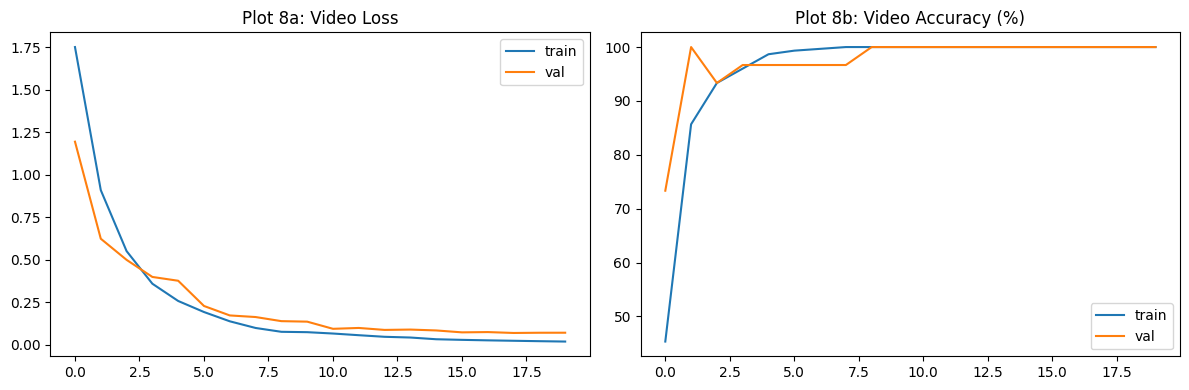

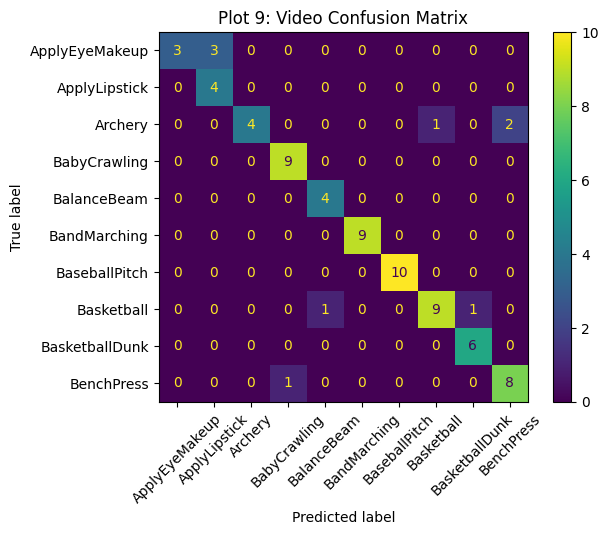

CNN-LSTM: acc=88.00%  F1=85.80%  params=168394


In [ ]:
def build_video_model(cell_type, D, n_classes, units=32):
    inp = Input(shape=(N_FRAMES, D))
    if cell_type == "LSTM":
        x = layers.LSTM(units)(inp)
    else:
        x = layers.GRU(units)(inp)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

VIDEO_CELL = "LSTM"   # switch to "GRU" to compare, per Additional Exercise 6
video_model = build_video_model(VIDEO_CELL, FEATURE_DIM, len(video_classes))
video_hist = video_model.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val),
                              epochs=20, batch_size=8, verbose=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(video_hist.history["loss"], label="train")
axes[0].plot(video_hist.history["val_loss"], label="val")
axes[0].set_title("Plot 8a: Video Loss"); axes[0].legend()
axes[1].plot([a*100 for a in video_hist.history["accuracy"]], label="train")
axes[1].plot([a*100 for a in video_hist.history["val_accuracy"]], label="val")
axes[1].set_title("Plot 8b: Video Accuracy (%)"); axes[1].legend()
plt.tight_layout()
plt.show()

yv_pred = np.argmax(video_model.predict(Xv_test, verbose=0), axis=1)
cm_video = confusion_matrix(yv_test, yv_pred)
ConfusionMatrixDisplay(cm_video, display_labels=video_classes).plot(xticks_rotation=45)
plt.title("Plot 9: Video Confusion Matrix")
plt.show()

video_acc = accuracy_score(yv_test, yv_pred) * 100
video_f1 = f1_score(yv_test, yv_pred, average="macro", zero_division=0) * 100
video_prec = precision_score(yv_test, yv_pred, average="macro", zero_division=0) * 100
video_rec = recall_score(yv_test, yv_pred, average="macro", zero_division=0) * 100
video_params = video_model.count_params()
print(f"CNN-{VIDEO_CELL}: acc={video_acc:.2f}%  F1={video_f1:.2f}%  params={video_params}")

# Required observation: state FEATURE_DIM and the (B,10,D) tensor shape above in the report.


## 11. Sequence-to-Sequence Learning: Synthetic Reversal Task

Encoder–decoder LSTM, e.g. `[1, 4, 7, 2] -> [2, 7, 4, 1]`, trained with teacher forcing.


In [ ]:
VOCAB_SIZE = 10          # digits 0-9
SEQ_LEN = 5
N_SAMPLES = 20000
START_TOKEN = VOCAB_SIZE      # index 10 = <START>
PAD_TOKEN = VOCAB_SIZE + 1    # index 11 = <PAD> (unused here, fixed length)
FULL_VOCAB = VOCAB_SIZE + 2

def generate_reversal_data(n_samples, seq_len):
    X = np.random.randint(0, VOCAB_SIZE, size=(n_samples, seq_len))
    y = X[:, ::-1]
    return X, y

X_seq, y_seq = generate_reversal_data(N_SAMPLES, SEQ_LEN)

# Decoder input = <START> followed by target shifted right (teacher forcing)
decoder_input = np.concatenate(
    [np.full((N_SAMPLES, 1), START_TOKEN), y_seq[:, :-1]], axis=1)

Xtr, Xte, dec_in_tr, dec_in_te, ytr_seq, yte_seq = train_test_split(
    X_seq, decoder_input, y_seq, test_size=0.15, random_state=SEED)

print("Train:", Xtr.shape, "Test:", Xte.shape)


Train: (17000, 5) Test: (3000, 5)


In [ ]:
EMBED_DIM = 32
UNITS = 64

# --- Training model (teacher forcing) ---
enc_inputs = Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(FULL_VOCAB, EMBED_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(UNITS, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

dec_inputs = Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(FULL_VOCAB, EMBED_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(UNITS, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])

s2s_hist = seq2seq_model.fit([Xtr, dec_in_tr], ytr_seq,
                              validation_split=0.1, epochs=15, batch_size=64, verbose=1)

# --- Inference-time encoder/decoder (no teacher forcing: feed prediction back in) ---
encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_input_h = Input(shape=(UNITS,))
dec_state_input_c = Input(shape=(UNITS,))
dec_single_input = Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_input)
dec_single_out, dec_h, dec_c = dec_lstm(
    dec_single_emb, initial_state=[dec_state_input_h, dec_state_input_c])
dec_single_out = dec_dense(dec_single_out)
decoder_model = models.Model(
    [dec_single_input, dec_state_input_h, dec_state_input_c],
    [dec_single_out, dec_h, dec_c])

def predict_sequences_batch(input_seqs, batch_size=512):
    """Greedy decode the WHOLE array of input sequences at once, decoding
    step-by-step across the batch (SEQ_LEN calls total) instead of looping
    example-by-example (which triggers heavy tf.function retracing and is
    extremely slow for a few thousand examples)."""
    n = input_seqs.shape[0]
    all_outputs = np.zeros((n, SEQ_LEN), dtype=int)
    for start in range(0, n, batch_size):
        chunk = input_seqs[start:start + batch_size]
        states = encoder_model.predict(chunk, verbose=0)
        b = chunk.shape[0]
        target = np.full((b, 1), START_TOKEN)
        for t in range(SEQ_LEN):
            tok_probs, h, c = decoder_model.predict([target] + states, verbose=0)
            tok = np.argmax(tok_probs[:, -1, :], axis=-1)
            all_outputs[start:start + b, t] = tok
            target = tok.reshape(-1, 1)
            states = [h, c]
    return all_outputs


Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5528 - loss: 1.3098 - val_accuracy: 0.9352 - val_loss: 0.3585
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9759 - loss: 0.1844 - val_accuracy: 0.9926 - val_loss: 0.0967
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9971 - loss: 0.0633 - val_accuracy: 0.9975 - val_loss: 0.0483
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9993 - loss: 0.0318 - val_accuracy: 0.9996 - val_loss: 0.0240
Epoch 5/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9999 - loss: 0.0180 - val_accuracy: 0.9999 - val_loss: 0.0154
Epoch 6/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9978 - loss: 0.0202 - val_accuracy: 1.0000 - val_loss: 0.0107
Epoch 7/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9999 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 8/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 

### 11.1 Seq2seq evaluation — token accuracy & sequence accuracy

In [ ]:
preds = predict_sequences_batch(Xte)               # shape (N_test, SEQ_LEN)

correct_tokens = int((preds == yte_seq).sum())
total_tokens = preds.size
correct_seqs = int(np.all(preds == yte_seq, axis=1).sum())

token_acc = correct_tokens / total_tokens
seq_acc = correct_seqs / len(Xte)
sample_rows = [(list(Xte[i]), list(preds[i])) for i in range(5)]

print(f"Token accuracy:    {token_acc*100:.2f}%")
print(f"Sequence accuracy: {seq_acc*100:.2f}%")
print(f"Final training loss:   {s2s_hist.history['loss'][-1]:.4f}")
print(f"Final validation loss: {s2s_hist.history['val_loss'][-1]:.4f}")

print("\nSample predictions:")
for inp, pred in sample_rows:
    print(f"  Input: {inp}  ->  Predicted: {pred}")

# Required inference: sequence accuracy < token accuracy because ONE wrong token anywhere
# in the sequence fails the whole sequence, even if every other token is correct — a 90%
# per-token rate over 5 tokens gives only ~0.9^5 ≈ 59% expected sequence accuracy.


Token accuracy:    100.00%
Sequence accuracy: 100.00%
Final training loss:   0.0013
Final validation loss: 0.0014

Sample predictions:
  Input: [np.int64(7), np.int64(9), np.int64(5), np.int64(0), np.int64(0)]  ->  Predicted: [np.int64(0), np.int64(0), np.int64(5), np.int64(9), np.int64(7)]
  Input: [np.int64(2), np.int64(1), np.int64(8), np.int64(1), np.int64(5)]  ->  Predicted: [np.int64(5), np.int64(1), np.int64(8), np.int64(1), np.int64(2)]
  Input: [np.int64(3), np.int64(7), np.int64(1), np.int64(3), np.int64(0)]  ->  Predicted: [np.int64(0), np.int64(3), np.int64(1), np.int64(7), np.int64(3)]
  Input: [np.int64(7), np.int64(4), np.int64(8), np.int64(8), np.int64(0)]  ->  Predicted: [np.int64(0), np.int64(8), np.int64(8), np.int64(4), np.int64(7)]
  Input: [np.int64(7), np.int64(2), np.int64(1), np.int64(7), np.int64(5)]  ->  Predicted: [np.int64(5), np.int64(7), np.int64(1), np.int64(2), np.int64(7)]


## 12. Consolidated Results

In [ ]:
consolidated = pd.DataFrame({
    "RNN":       [results["RNN"]["accuracy"], results["RNN"]["precision"],
                  results["RNN"]["recall"], results["RNN"]["f1"], results["RNN"]["n_params"]],
    "LSTM":      [results["LSTM"]["accuracy"], results["LSTM"]["precision"],
                  results["LSTM"]["recall"], results["LSTM"]["f1"], results["LSTM"]["n_params"]],
    "GRU":       [results["GRU"]["accuracy"], results["GRU"]["precision"],
                  results["GRU"]["recall"], results["GRU"]["f1"], results["GRU"]["n_params"]],
    f"CNN-{VIDEO_CELL}": [video_acc, video_prec, video_rec, video_f1, video_params],
}, index=["Accuracy", "Precision", "Recall", "F1", "Parameters"]).T
display(consolidated)

seq2seq_table = pd.DataFrame({
    "Token Accuracy (%)": [token_acc * 100],
    "Sequence Accuracy (%)": [seq_acc * 100],
    "Final Train Loss": [s2s_hist.history["loss"][-1]],
    "Final Val Loss": [s2s_hist.history["val_loss"][-1]],
}, index=["Seq2Seq (reversal task)"])
display(seq2seq_table)


,Accuracy,Precision,Recall,F1,Parameters
RNN,89.320388,89.736272,89.341169,89.368540,1974.0
LSTM,94.951456,95.333844,95.292187,95.265172,6006.0
GRU,94.692557,95.056250,95.052700,95.040479,4758.0
CNN-LSTM,88.000000,88.285714,87.784993,85.797945,168394.0


,Token Accuracy (%),Sequence Accuracy (%),Final Train Loss,Final Val Loss
Seq2Seq (reversal task),100.0,100.0,0.001305,0.001378


In [ ]:
print('results' in dir())
print('video_acc' in dir())
print('token_acc' in dir())

True
True
True
